In [1]:
import numpy as np
import matplotlib.pyplot as plt

file1 = '/raid1/genli/Data_D2O/M1_data/runs_24531_24533_M1_20250728-08_dt0-10000_pe0-1000_mspe1.0_mcut10/aggregated_total_pe.pkl'
file2 = '/raid1/genli/Data_D2O/M2_data/runs_396_398_M2_20250728-08_dt0-10000_pe0-1000_mspe1.0_mcut10/aggregated_total_pe.pkl'

data1 = np.load(file1, allow_pickle=True)
data2 = np.load(file2, allow_pickle=True)

print(data1)

centers1 = data1['centers']
centers2 = data2['centers']
sum_area1 = data1['hist']
sum_area2 = data2['hist']
err1 = data1['errors']
err2 = data2['errors']

{'centers': array([  5.,  15.,  25.,  35.,  45.,  55.,  65.,  75.,  85.,  95., 105.,
       115., 125., 135., 145., 155., 165., 175., 185., 195., 205., 215.,
       225., 235., 245., 255., 265., 275., 285., 295., 305., 315., 325.,
       335., 345., 355., 365., 375., 385., 395., 405., 415., 425., 435.,
       445., 455., 465., 475., 485., 495., 505., 515., 525., 535., 545.,
       555., 565., 575., 585., 595., 605., 615., 625., 635., 645., 655.,
       665., 675., 685., 695., 705., 715., 725., 735., 745., 755., 765.,
       775., 785., 795., 805., 815., 825., 835., 845., 855., 865., 875.,
       885., 895., 905., 915., 925., 935., 945., 955., 965., 975., 985.,
       995.]), 'hist': array([   7,   15,  137,  559,  875, 1090, 1221, 1144, 1286, 1300, 1350,
       1384, 1304, 1380, 1420, 1425, 1360, 1243, 1107, 1005,  917,  839,
        708,  645,  562,  485,  448,  419,  385,  322,  255,  266,  264,
        216,  190,  195,  155,  154,  121,   77,  105,  102,   74,   81,
        101,   6

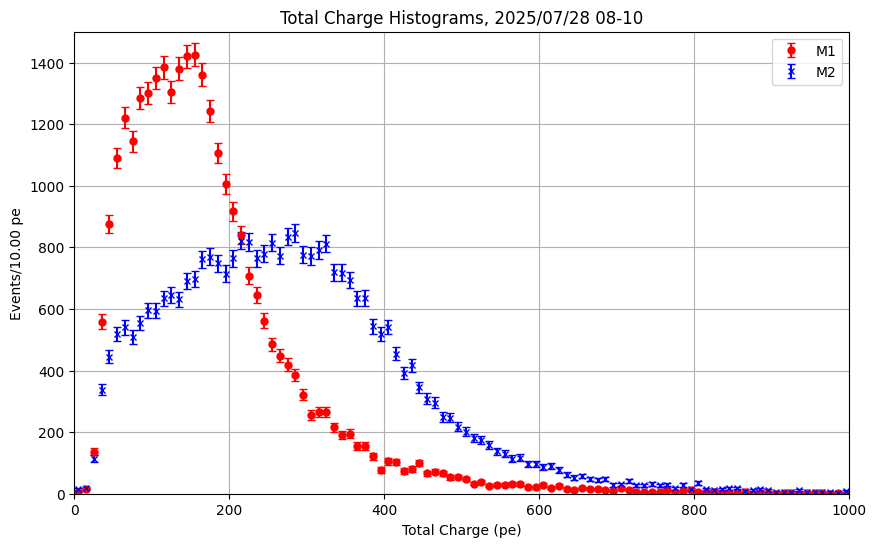

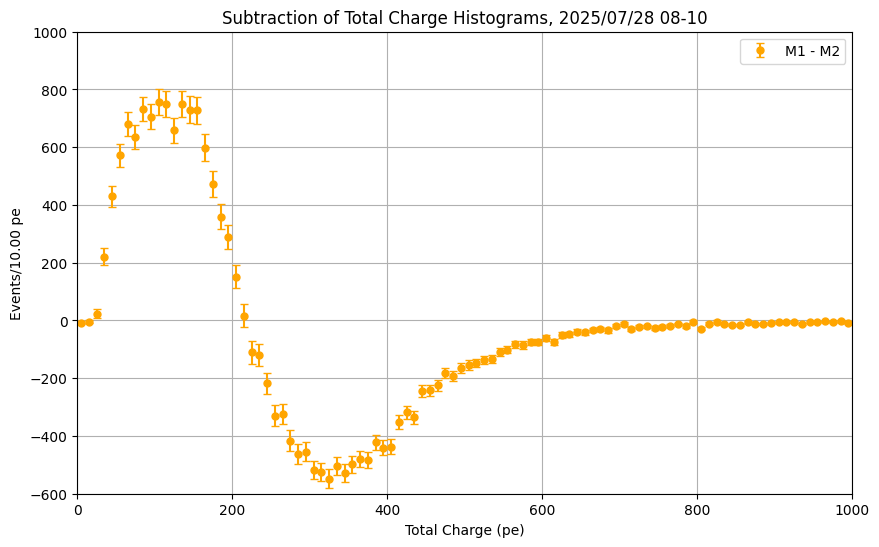

In [2]:
#Normalize the histograms and errors
# Convert to float to avoid casting errors
sum_area1 = sum_area1.astype(float)
sum_area2 = sum_area2.astype(float)
err1 = err1.astype(float)
err2 = err2.astype(float)
err_total = np.sqrt(err1**2 + err2**2)
bin_step = 1000 / centers1.size  # Assuming centers1 and centers2 have the same size
#plotting hist1 and hist2 on the same plot
plt.figure(figsize=(10, 6))
plt.errorbar(centers1, sum_area1, yerr=err1, fmt='o', label='M1', color='red', markersize=5, capsize=3)
plt.errorbar(centers2, sum_area2, yerr=err2, fmt='x', label='M2', color='blue', markersize=5, capsize=3)
plt.title('Total Charge Histograms, 2025/07/28 08-10')
plt.xlabel('Total Charge (pe)')
plt.ylabel(f'Events/{bin_step:.2f} pe')  # Adjusted ylabel to include bin step
plt.ylim(0, 1500)
plt.xlim(0, 1000)
plt.legend()
plt.grid()
# plt.savefig('total_charge_histograms.png')
plt.show()

#plotting subtraction hist1 - hist2
plt.figure(figsize=(10, 6))
plt.errorbar(centers1, sum_area1 - sum_area2, yerr=err_total, fmt='o', label='M1 - M2', color='orange', markersize=5, capsize=3)
plt.title('Subtraction of Total Charge Histograms, 2025/07/28 08-10')
plt.xlabel('Total Charge (pe)')
plt.ylabel(f'Events/{bin_step:.2f} pe')  # Adjusted ylabel to include bin step
plt.ylim(-600, 1000)
plt.xlim(0, 1000)
plt.legend()
plt.grid()
# plt.savefig('subtraction_histograms.png')
plt.show()

In [3]:
print("M1 events number:", np.sum(sum_area1))
print("M2 events number:", np.sum(sum_area2))
print("Subtraction events number:", np.sum(sum_area1 - sum_area2))

M1 events number: 29616.0
M2 events number: 31330.0
Subtraction events number: -1714.0
